In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import *
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import plotly.express as px

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [3]:
train_df.shape

(750000, 9)

In [4]:
test_df.shape

(250000, 8)

In [5]:
test_df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [7]:
train_df.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Duration of physical activity or exercise (in minutes). A direct measure of exercise volume impacting calories burned

Heart_Rate = Heart rate recorded during the activity (in beats per minute). Reflects intensity of the physical effort.

Body_Temp = Body temperature during the activity (in degrees Celsius). Can indicate metabolic rate or physiological response to exertion.

In [8]:
columns_with_nulls = train_df.isnull().any() & test_df.isnull().any()

In [9]:
columns_with_nulls

Age           False
Body_Temp     False
Calories      False
Duration      False
Heart_Rate    False
Height        False
Sex           False
Weight        False
id            False
dtype: bool

In [10]:
train_df["id"].nunique()

750000

In [11]:
train_df.dtypes

id              int64
Sex            object
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

In [12]:
train_df["Sex"].value_counts()

Sex
female    375721
male      374279
Name: count, dtype: int64

In [13]:
test_df["Sex"].value_counts()

Sex
female    125281
male      124719
Name: count, dtype: int64

In [14]:
# train_df['Sex'] = train_df['Sex'].map({'female': 0, 'male': 1})
# train_df

In [15]:
train_df

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [16]:
# if ['female', 'male'] in list(gen_cond):
#     train_df['Sex'] = train_df['Sex'].map({'female': 0, 'male': 1})
# else:
#     print("Already Done!")

In [17]:
# train_df['Sex'] = train_df['Sex'].replace({'female': 0, 'male': 1})

In [18]:
# %%time
# if "male" and "female" in train_df['Sex'].unique():
#   train_df['Sex'] = train_df['Sex'].map({'female': 0, 'male': 1})
# else:
#   print("No")

In [19]:
%%time
m = {"male": 1, "female": 0, 1: 1, 0: 0}
train_df["Sex"] = train_df["Sex"].map(m)

CPU times: total: 46.9 ms
Wall time: 40.8 ms


In [20]:
%%time
m = {"male": 1, "female": 0, 1: 1, 0: 0}
test_df["Sex"] = test_df["Sex"].map(m)

CPU times: total: 15.6 ms
Wall time: 12 ms


In [21]:
train_df

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,0,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,1,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,0,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,1,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,1,45,182.0,91.0,17.0,102.0,40.3,109.0


In [22]:
test_df

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,1,45,177.0,81.0,7.0,87.0,39.8
1,750001,1,26,200.0,97.0,20.0,101.0,40.5
2,750002,0,29,188.0,85.0,16.0,102.0,40.4
3,750003,0,39,172.0,73.0,20.0,107.0,40.6
4,750004,0,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,0,56,159.0,62.0,6.0,85.0,39.4
249996,999996,1,32,202.0,101.0,3.0,84.0,38.4
249997,999997,0,31,164.0,64.0,14.0,98.0,40.1
249998,999998,0,62,158.0,61.0,25.0,106.0,40.7


In [23]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  int64  
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 51.5 MB


In [24]:
numerical_feature = train_df.select_dtypes(include=["int64", "float64"]).columns
numerical_feature

Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [25]:
# fig = px.scatter_3d(
# 	data=train_df,
# 	x='Duration',
# 	y='Heart_Rate',
# 	z='Calories',
# 	color='Sex',
# 	size='Weight',
# 	hover_data=['Age', 'Height', 'Body_Temp'],
# 	title='3D Scatter: Duration vs Heart Rate vs Calories'
# )
# fig.show()

In [26]:
%%time
fig = px.scatter_3d(
    train_df.sample(n=100, random_state=42),
    x="Duration",
    y="Heart_Rate",
    z="Calories",
    color="Sex",
    size="Weight",
    hover_data=["Age", "Height", "Body_Temp"],
    title="3D Scatter: All Dimensions",
    labels={
        "Duration": "Duration (min)",
        "Heart_Rate": "Heart Rate (bpm)",
        "Calories": "Calories Burned (target)",
        "Weight": "Weight (kg)",
    },
)
fig.update_layout(height=700, width=1000)
fig.show()

CPU times: total: 1.7 s
Wall time: 1.92 s


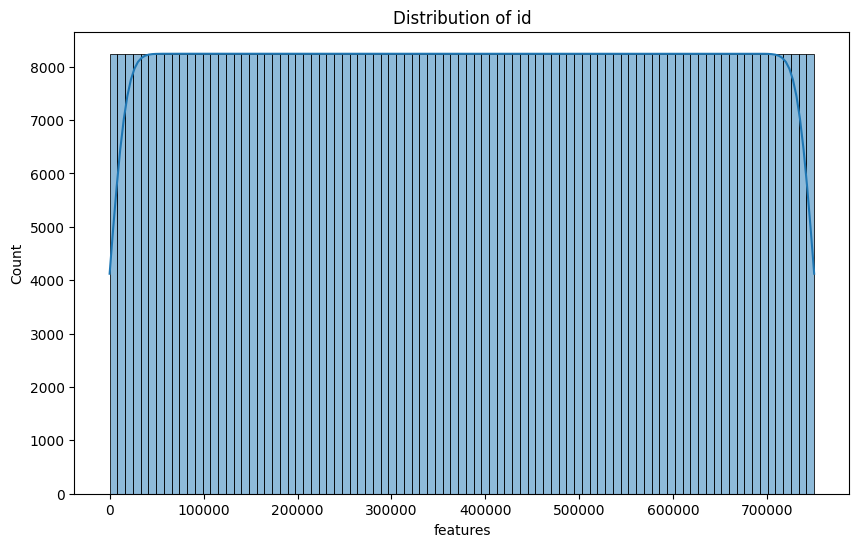

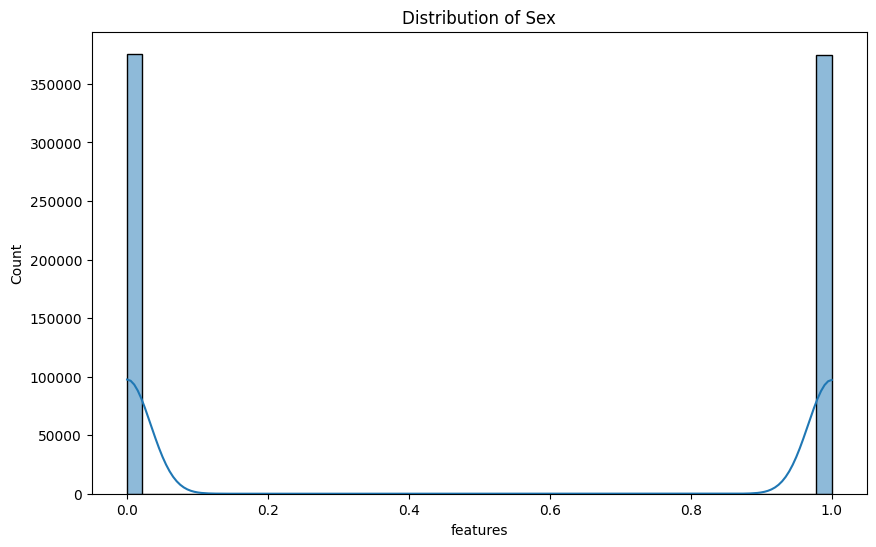

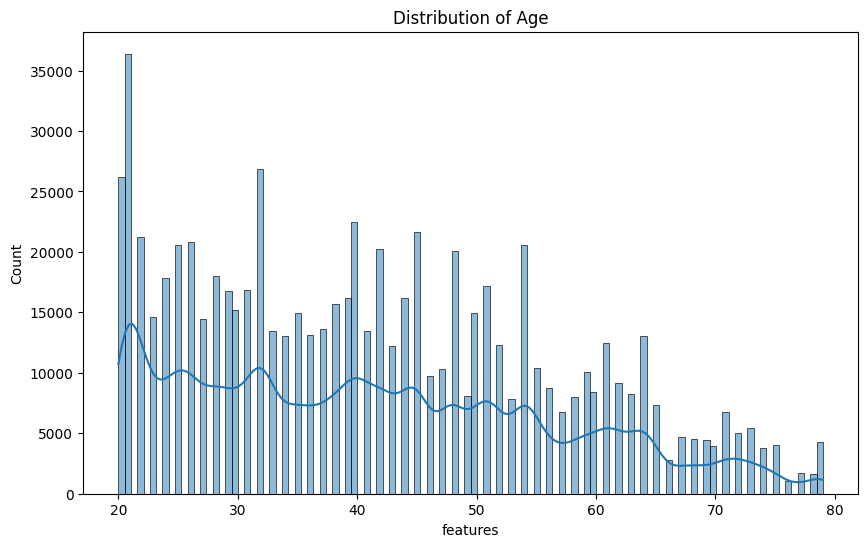

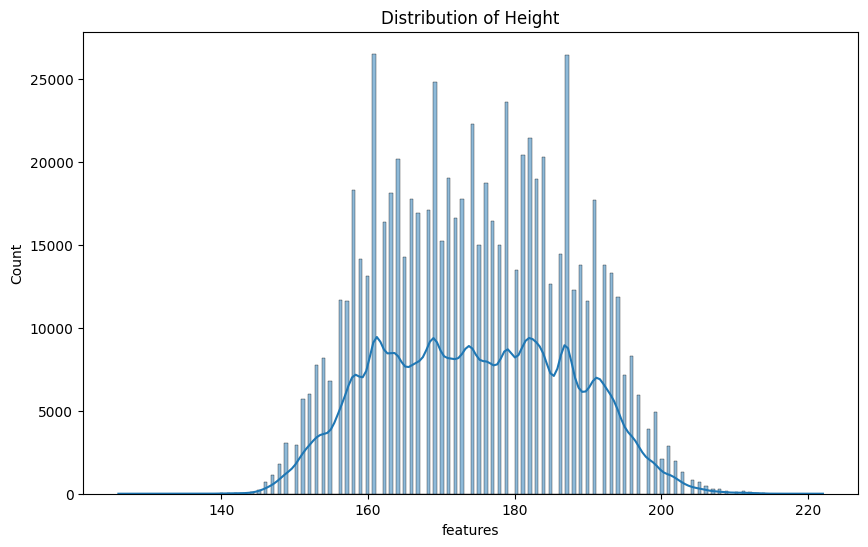

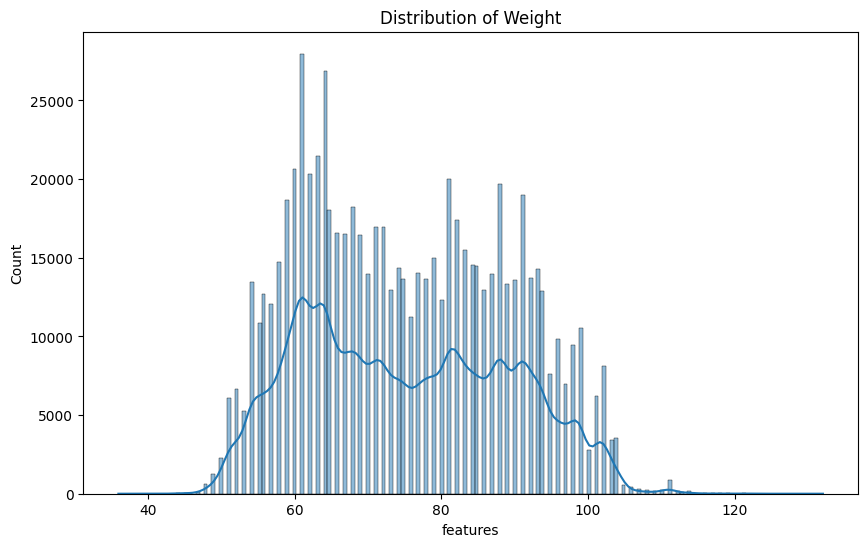

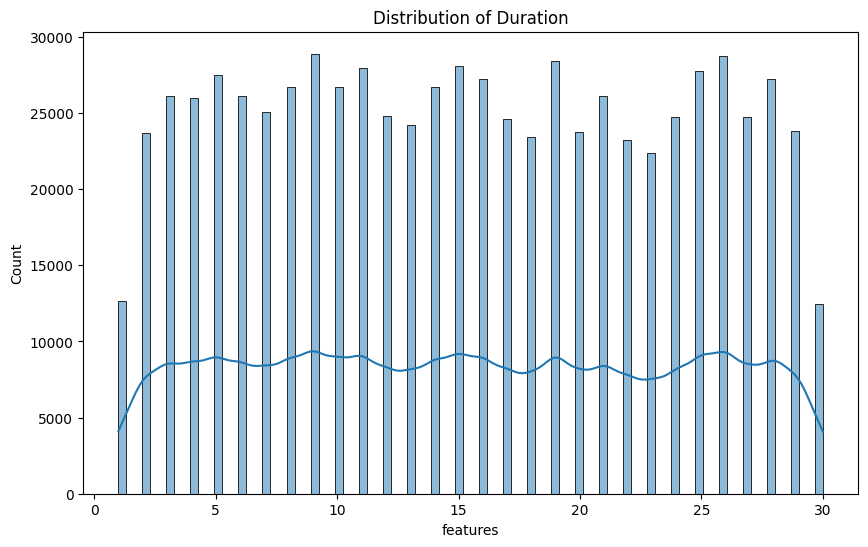

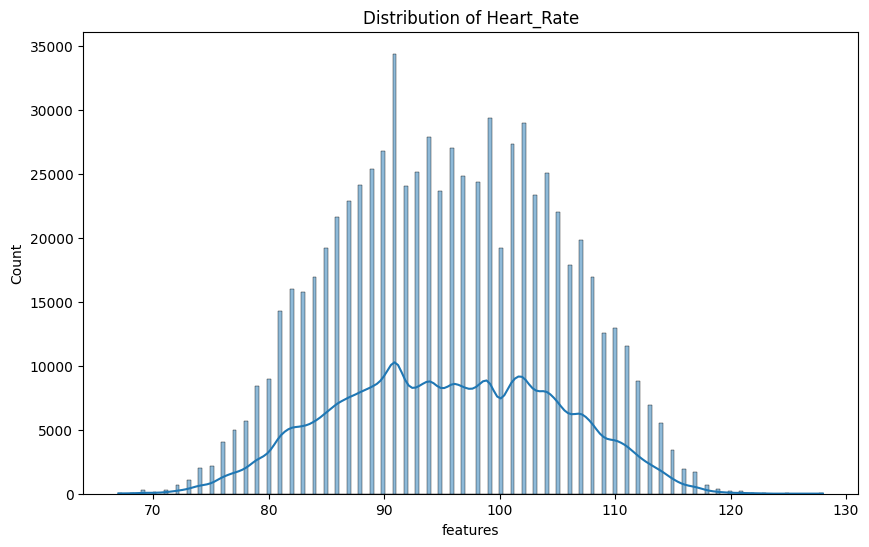

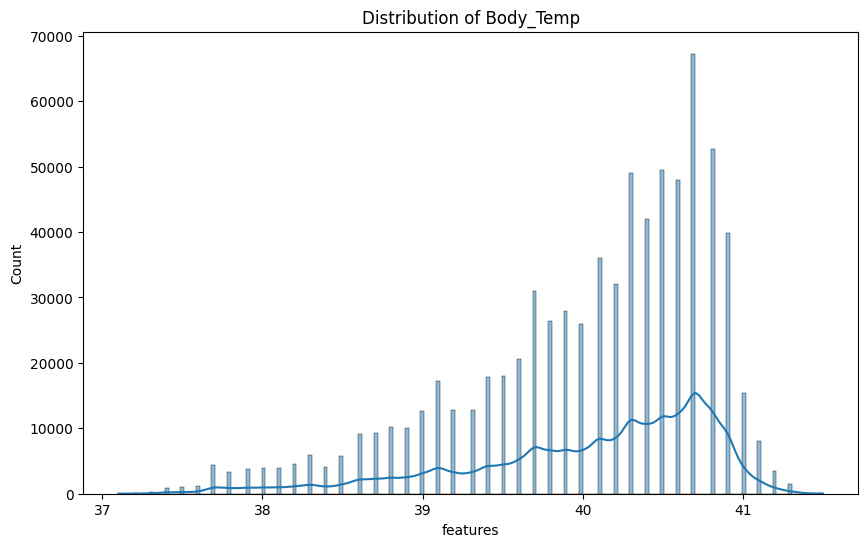

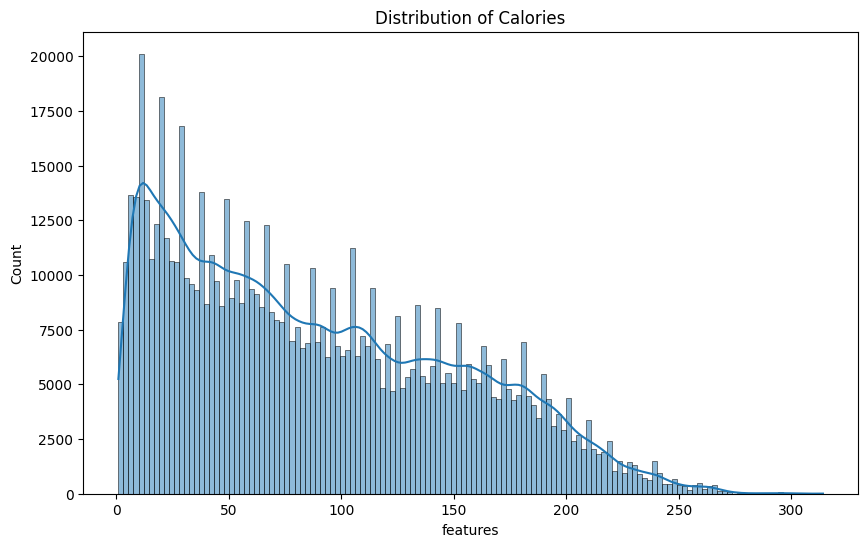

In [27]:
for features in numerical_feature:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_df[features], kde=True)
    plt.title(f"Distribution of {features}")
    plt.xlabel("features")
    plt.show()

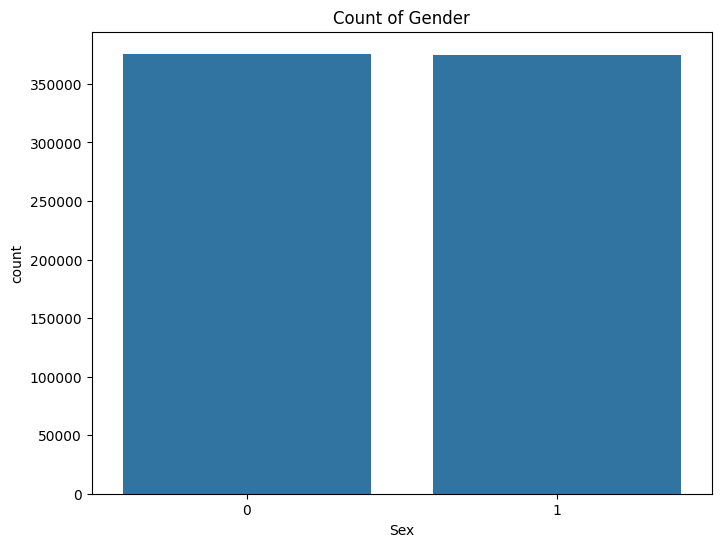

In [28]:
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x="Sex")
plt.title("Count of Gender")
plt.show()

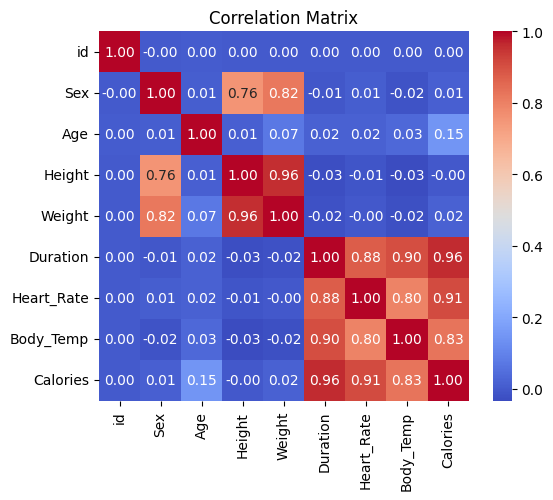

In [29]:
plt.Figure(figsize=(12, 8))
sns.heatmap(
    train_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
)
plt.title("Correlation Matrix")
plt.show()

In [30]:
X = train_df.drop(columns=["Calories", "id"], axis=1)
y = train_df["Calories"]

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
reg = linear_model.LinearRegression().fit(X, y)

In [33]:
reg.coef_

array([ -1.69638188,   0.53207573,  -0.14626323,   0.26964886,
         6.75960902,   1.94866858, -18.18538501])

In [34]:
reg.intercept_

510.1474418540663

In [35]:
X.shape

(750000, 7)

In [36]:
len(y)

750000

In [37]:
X.shape[1]

7

In [38]:
y_pred = reg.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")


adj_r_val = 1 - (1 - r2) * (X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)
print(f"Adjusted R Squared: {adj_r_val:.4f}")

if r2 > 0.9:
    print("Excellent! Model explains > 90% of variance")
elif r2 > 0.7:
    print("Good! Model explains >70% of variance")
elif r2 > 0.5:
    print("Fair! Model explains >50% of variance")
else:
    print("Poor! Model needs improvement")

Mean Absolute Error: 8.0814
Mean Squared Error: 122.2945
R2 Score: 0.9684
Root Mean Squared Error: 11.0587
Adjusted R Squared: 0.9684
Excellent! Model explains > 90% of variance


On Average, predictions are off by +- 8.08 calories

they're only ±11 calories off (RMSE)

Model explains 96.8 of the variation in calories 

##### Benchmark
Score	Quality

**R² > 0.95	Excellent** , 

**0.80 - 0.95	Good** ,

**0.50 - 0.80	Fair** ,

**< 0.50	 Poor**

In [39]:
# test02 =   1 - (1-r2) * ( len(y) - 1 ) / ( len(y) - X.shape[1] - 1 )
# test02

In [40]:
# n = X.shape[0]
# p = X.shape[1]
# test01 =  1 - (1 - r2) * (n - 1) / (n - p - 1)
# print(f"Adjusted R-squared: {test01}")

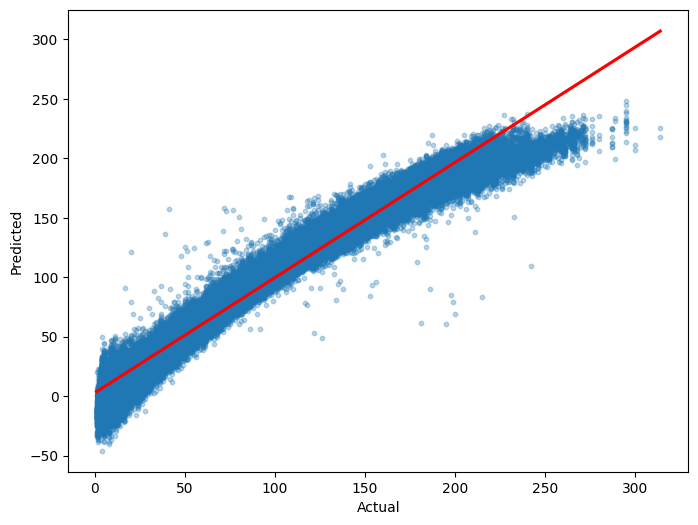

In [41]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x=y_val, y=y_pred, scatter_kws={"alpha": 0.3, "s": 10}, line_kws={"color": "red"}
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("")
plt.show()

this graphs shows if it's biased or not (high or low)

if the line doesn't align with y= x , it indicates bias in the model 

X axis real (actual) calories burned from the data 

Y = calories model predicted 

In [42]:
test_df.drop("id", axis=1, inplace=True)

In [43]:
X_test = test_df
print("Training columns ", X.columns.to_list())
print("Test columns ", X_test.columns.to_list())

Training columns  ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
Test columns  ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


Prediction on Test data 

In [44]:
test_predcition = reg.predict(test_df)
test_df["Calories"] = test_predcition

In [45]:
test_predcition

array([ 21.42054033, 114.68793682,  93.22868926, ...,  76.28225523,
       171.87905257,  88.49211001])

In [46]:
test_df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,45,177.0,81.0,7.0,87.0,39.8,21.420540
1,1,26,200.0,97.0,20.0,101.0,40.5,114.687937
2,0,29,188.0,85.0,16.0,102.0,40.4,93.228689
3,0,39,172.0,73.0,20.0,107.0,40.6,130.798574
4,0,30,173.0,67.0,16.0,94.0,40.5,73.693147
...,...,...,...,...,...,...,...,...
249995,0,56,159.0,62.0,6.0,85.0,39.4,23.096373
249996,1,32,202.0,101.0,3.0,84.0,38.4,8.815050
249997,0,31,164.0,64.0,14.0,98.0,40.1,76.282255
249998,0,62,158.0,61.0,25.0,106.0,40.7,171.879053


Text(0.5, 1.0, 'Residuals Plot')

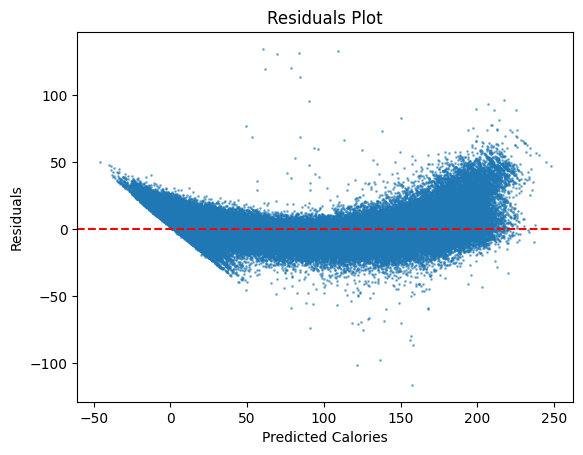

In [47]:
difference = y_val - y_pred
plt.scatter(y_pred, difference, alpha=0.5, s=1)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Residuals Plot")

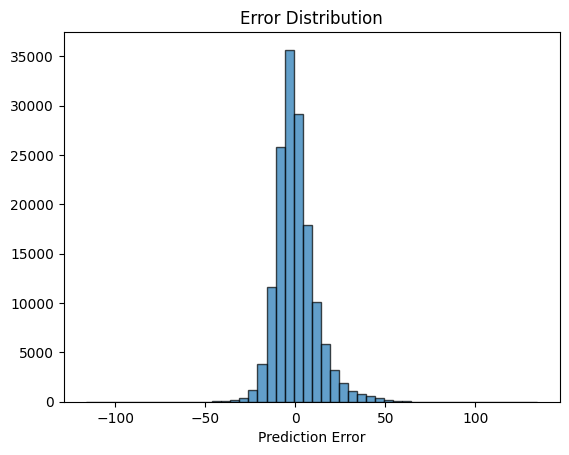

In [48]:
plt.Figure(figsize=(10, 4))
plt.hist(difference, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.show()

%%ignore

In [49]:
sample_df = train_df.sample(n=5000, random_state=42)
sample_df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
404846,404846,0,56,163.0,61.0,29.0,108.0,40.8,200.0
580313,580313,1,44,179.0,87.0,13.0,94.0,40.3,64.0
552086,552086,1,41,186.0,84.0,10.0,89.0,39.9,39.0
370876,370876,0,38,161.0,58.0,19.0,98.0,40.6,103.0
239330,239330,1,57,181.0,77.0,9.0,98.0,40.0,52.0


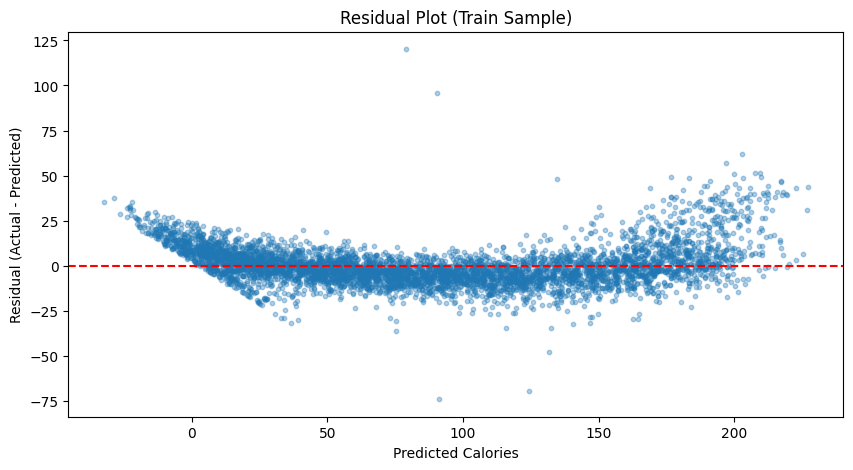

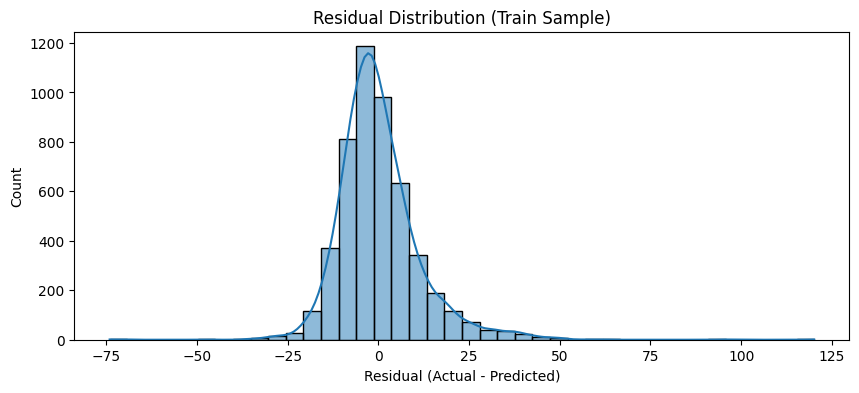

In [50]:
sample_n = 5000
train_s = train_df.sample(n=sample_n, random_state=42)
X_s = train_s.drop(["Calories", "id"], axis=1)
y_s = train_s["Calories"]
y_pred_s = reg.predict(X_s)
residuals = y_s - y_pred_s


plt.figure(figsize=(10, 5))
plt.scatter(y_pred_s, residuals, s=10, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Calories")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Train Sample)")
plt.show()
plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution (Train Sample)")
plt.show()

The curve shape means errors are not random; the model systematically under‑ or over‑predicts for low and high calorie values.

hist is roughly bell- shaped and centered near 0 so avg is small , but there are long tails on both side more on right 
there are many rows under predicts calorie 

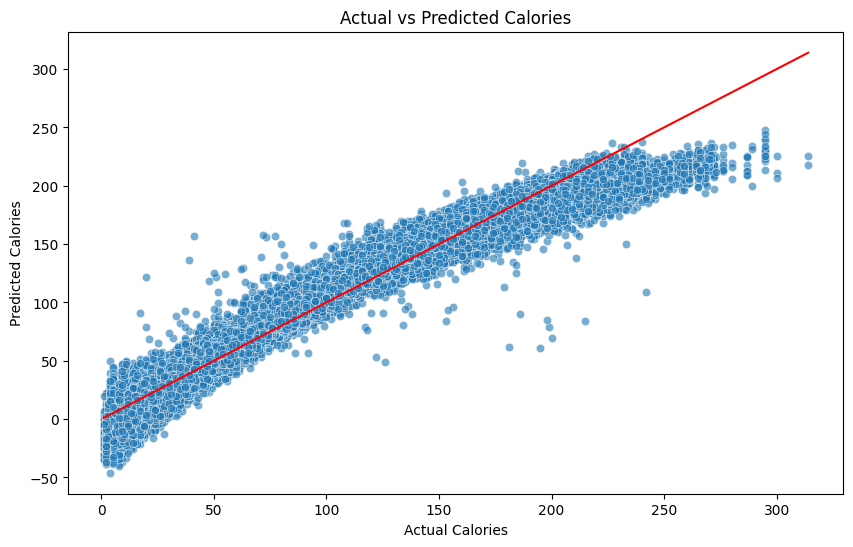

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.6)
sns.lineplot(x=[y_val.min(), y_val.max()], y=[y_val.min(), y_val.max()], color="red")
plt.title("Actual vs Predicted Calories")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.show()

Red line is perfect prediction line y=x:  Points on the line are exact , points above mean over - prediction , and points below mean under - prediction 

spread gets wider as actual calories increases , which means errors are larger for higher calorie cases 

Some dots are far from the line = outliers , meaning model sometime making big mistakes for certain records 

In [53]:
import pickle

with open("model_pickle", "wb") as f:
    pickle.dump(reg, f)

In [54]:
with open("model_pickle", "rb") as f:
    test = pickle.load(f)

In [56]:
X

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,1,36,189.0,82.0,26.0,101.0,41.0
1,0,64,163.0,60.0,8.0,85.0,39.7
2,0,51,161.0,64.0,7.0,84.0,39.8
3,1,20,192.0,90.0,25.0,105.0,40.7
4,0,38,166.0,61.0,25.0,102.0,40.6
...,...,...,...,...,...,...,...
749995,1,28,193.0,97.0,30.0,114.0,40.9
749996,0,64,165.0,63.0,18.0,92.0,40.5
749997,1,60,162.0,67.0,29.0,113.0,40.9
749998,1,45,182.0,91.0,17.0,102.0,40.3


In [57]:
X.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='object')

In [58]:
test_data = pd.DataFrame(
    {
        "Sex": [1, 0, 1, 0, 1],
        "Age": [25, 45, 30, 55, 40],
        "Height": [180, 165, 175, 160, 185],
        "Weight": [75, 60, 80, 65, 90],
        "Duration": [30, 15, 45, 10, 20],
        "Heart_Rate": [120, 95, 130, 85, 110],
        "Body_Temp": [40.5, 39.8, 41.0, 39.5, 40.2],
    }
)

predictions = test.predict(test_data)

print("Predicted Calories Burned:")
for i, cal in enumerate(predictions):
    print(f"Person {i+1}: {cal:.1f} calories")

Predicted Calories Burned:
Person 1: 215.8 calories
Person 2: 88.9 calories
Person 3: 332.3 calories
Person 4: 48.4 calories
Person 5: 145.4 calories
